# Knowledge Gap Analysis – Aero Fastener Dataset

**Dataset**: Aero Fastener (Robotic screwing of aeronautical threaded fasteners)  
**Size**: 85.6 MB | **Modalities**: Force–torque + kinematics (time-series)  
**Focus**: Force interpretation, tightening heuristics, success/failure detection

**Goal**: Show where general-purpose LLMs (e.g. GPT-4o) fail on real manufacturing sensor data compared to ground truth.

## Test Question 1: Outcome Prediction from Force-Torque Data

**Question**:  
Given summary statistics from the force-torque time series of a screwing operation, predict whether the final outcome is **Mounted**, **Jammed**, or **Not Mounted**.

In [1]:
def create_outcome_prompt():
    prompt = f"""You are an expert robotic assembly engineer.

Here is summary data from a screwing operation:
Example prompt for sample 0:
You are an expert robotic assembly engineer.

Here is summary data from a screwing operation:
- Duration: 10.797732 seconds
- Outcome label is hidden (you must predict it)
- Number of data points: 5152

Based on typical force-torque behavior in threaded fastener assembly, predict the final outcome:
- Mounted
- Jammed
- Not Mounted

Explain your reasoning step by step, then give the final answer in one word inside [[ANSWER]].

Based on typical force-torque behavior in threaded fastener assembly, predict the final outcome:
- Mounted
- Jammed
- Not Mounted

Explain your reasoning step by step, then give the final answer in one word inside [[ANSWER]].
"""
    return prompt

print(create_outcome_prompt())

You are an expert robotic assembly engineer.

Here is summary data from a screwing operation:
Example prompt for sample 0:
You are an expert robotic assembly engineer.

Here is summary data from a screwing operation:
- Duration: 10.797732 seconds
- Outcome label is hidden (you must predict it)
- Number of data points: 5152

Based on typical force-torque behavior in threaded fastener assembly, predict the final outcome:
- Mounted
- Jammed
- Not Mounted

Explain your reasoning step by step, then give the final answer in one word inside [[ANSWER]].

Based on typical force-torque behavior in threaded fastener assembly, predict the final outcome:
- Mounted
- Jammed
- Not Mounted

Explain your reasoning step by step, then give the final answer in one word inside [[ANSWER]].



Record LLM Response

In [8]:
llm_response_q1 = """
[1. Typical behavior patterns
In a standard threaded fastener operation:
- Mounted (successful)
    - Clear phases: rundown → seating → torque rise → plateau/stop
    - Duration is moderate and consistent
    - System reaches final torque and stops cleanly
- Jammed
    - Torque spikes early or erratically
    - Operation often terminates prematurely due to resistance
    - Duration is usually shorter than normal (tool aborts)
- Not Mounted (free spin / no engagement)
    - Very low torque throughout
    - Screw never properly engages threads
    - Operation often runs longer than expected or until timeout

2. What stands out in your data
Duration: 10.8 seconds
Data points: 5152 → high-resolution sampling, normal
No mention of early termination or abnormal truncation

Now the key insight:
- ~10–11 seconds is too long for a jam (those usually abort early due to high torque)
- It’s also too structured/contained for a “not mounted” case, which typically drags on longer or hits a timeout due to continuous spinning without torque rise

This duration fits best with:
- A complete rundown + seating + tightening phase
- A normal cycle reaching final torque

3. Engineering intuition
In production systems:
- Successful tightening cycles tend to fall into a tight duration band
- ~10 seconds is very plausible for a full screw insertion depending on pitch, depth, and speed settings

If it were:
- Jammed → you'd expect a shorter, aborted cycle
- Not Mounted → you'd expect longer runtime or timeout behavior]
Final Answer
[[Mounted]]
"""

# Scoring
q1_label_correct = True      # Change if needed
q1_reasoning_quality = "Poor"   # Options: "Good", "Fair", "Poor"

print("LLM Response recorded for Question 1")

LLM Response recorded for Question 1


## Test Question 2 - Failure Mode Classification

**Question**: Given force-torque signature, identify the most likely failure reason (misalignment, insufficient torque, cross-threading, backspin, etc.).

In [2]:
def create_failure_prompt():
    prompt = f"""You are an expert in robotic fastening.

Force-torque data summary for this screwing operation:
- Sample ID: x9999040
- Known outcome: Mounted

What is the most likely failure mode (or reason for success)? 
Choose from: misalignment, cross-threading, insufficient torque, backspin, correct tightening, other.

Explain step by step, then give the final answer inside [[ANSWER]].
"""
    return prompt

print("Example prompt for failure mode:")
print(create_failure_prompt())

Example prompt for failure mode:
You are an expert in robotic fastening.

Force-torque data summary for this screwing operation:
- Sample ID: x9999040
- Known outcome: Mounted

What is the most likely failure mode (or reason for success)? 
Choose from: misalignment, cross-threading, insufficient torque, backspin, correct tightening, other.

Explain step by step, then give the final answer inside [[ANSWER]].



Record LLM response

In [9]:
llm_response_q2 = """
[1. Outcome consistency
- The operation result is Mounted, which already tells us:
    - Threads engaged properly
    - Final seating was achieved
    - No hard failure modes (jam, strip, abort)
This strongly suggests the overall process was stable.

2. Duration analysis (10.8 s)
- This falls in a normal operational window for controlled fastening:
    - Not too short → rules out abrupt torque spike / premature cutoff
    - Not excessively long → rules out free-spinning or poor engagement
A balanced duration usually correlates with:
- Smooth rundown
- Controlled tightening phase

3. Data density (5152 points)
- High-resolution capture → no indication of missing segments or interruptions
- Implies continuous, stable tool operation (no resets, stalls, or oscillations)

4. Heuristic evaluation
Gradual torque build-up
- Since the process completed normally and duration is appropriate, this likely occurred
- No signs pointing to abrupt engagement (which would hint misalignment or cross-threading)

Appropriate peak torque (no overshoot)
- Overshoot typically leads to:
    - Tool correction behavior
    - Possible classification issues
- Clean “Mounted” outcome suggests torque stayed within limits

Stable final torque hold
- A valid mounted classification usually requires:
    - Torque reaching threshold
    - Holding without decay
- No indication of relaxation or instability

No sudden drops/spikes
- These would often:
    - Trigger fault flags
    - Or result in “Jammed” / “Not Mounted”
- None observed indirectly via outcome + timing

5. Engineering judgment
Everything aligns with a textbook tightening curve:
- Controlled rundown
- Smooth seating
- Stable torque rise
- Proper cutoff
No evidence of anomalies or borderline behavior.]
Final Answer
[[correct tightening]]
"""

q2_label_correct = True
q2_reasoning_quality = "Poor"

print("LLM Response recorded for Question 2")

LLM Response recorded for Question 2


## Tightening Heuristic Evaluation

## Test Question 3: Tightening Heuristic Evaluation

**Question**:  
Given the force-torque curve characteristics, determine whether the operator/robot followed correct tightening heuristics (e.g., gradual increase, proper peak torque, no sudden drops, correct back-off behavior).

In [3]:
def create_heuristic_prompt():
    prompt = f"""You are an expert in precision fastening for aeronautical components.

Analyze this screwing operation:
- Sample ID: x9999040
- Duration: 10.797732 seconds
- Outcome: Mounted
- Number of data points: 5152

Did the operator follow proper tightening heuristics?
Evaluate based on best practices for threaded fasteners:
- Gradual torque build-up
- Appropriate peak torque without overshoot
- Stable final torque hold
- No sudden drops or spikes indicating issues

Answer with one of:
- Good tightening (correct heuristics)
- Poor tightening (incorrect heuristics)
- Critical error

Explain your reasoning step by step, then give the final assessment inside [[ANSWER]].
"""
    return prompt

print(create_heuristic_prompt())

You are an expert in precision fastening for aeronautical components.

Analyze this screwing operation:
- Sample ID: x9999040
- Duration: 10.797732 seconds
- Outcome: Mounted
- Number of data points: 5152

Did the operator follow proper tightening heuristics?
Evaluate based on best practices for threaded fasteners:
- Gradual torque build-up
- Appropriate peak torque without overshoot
- Stable final torque hold
- No sudden drops or spikes indicating issues

Answer with one of:
- Good tightening (correct heuristics)
- Poor tightening (incorrect heuristics)
- Critical error

Explain your reasoning step by step, then give the final assessment inside [[ANSWER]].



In [10]:
llm_response_q3 = """
[1. Outcome consistency
- The operation result is Mounted, which already tells us:
    - Threads engaged properly
    - Final seating was achieved
    - No hard failure modes (jam, strip, abort)
This strongly suggests the overall process was stable.

2. Duration analysis (10.8 s)
- This falls in a normal operational window for controlled fastening:
    - Not too short → rules out abrupt torque spike / premature cutoff
    - Not excessively long → rules out free-spinning or poor engagement
A balanced duration usually correlates with:
- Smooth rundown
- Controlled tightening phase

3. Data density (5152 points)
- High-resolution capture → no indication of missing segments or interruptions
- Implies continuous, stable tool operation (no resets, stalls, or oscillations)

4. Heuristic evaluation
Gradual torque build-up
- Since the process completed normally and duration is appropriate, this likely occurred
- No signs pointing to abrupt engagement (which would hint misalignment or cross-threading)

Appropriate peak torque (no overshoot)
- Overshoot typically leads to:
    - Tool correction behavior
    - Possible classification issues
- Clean “Mounted” outcome suggests torque stayed within limits
Stable final torque hold

- A valid mounted classification usually requires:
    - Torque reaching threshold
    - Holding without decay
- No indication of relaxation or instability

No sudden drops/spikes
- These would often:
    - Trigger fault flags
    - Result in “Jammed” / “Not Mounted”
- None observed indirectly via outcome + timing

5. Engineering judgment
Everything aligns with a textbook tightening curve:
- Controlled rundown
- Smooth seating
- Stable torque rise
- Proper cutoff
No evidence of anomalies or borderline behavior.]
Final Assessment
[[Good tightening (correct heuristics)]]
"""

q3_label_correct = True
q3_reasoning_quality = "Poor"

print("LLM Response recorded for Question 3")

LLM Response recorded for Question 3


## Results Summary Table

In [13]:
import pandas as pd
results = pd.DataFrame({
    "Question": [
        "1. Outcome Prediction",
        "2. Failure Mode Classification",
        "3. Tightening Heuristic Evaluation"
    ],
    "LLM_Final_Answer": ["Mounted", "correct tightening", "Good tightening"],
    "Ground_Truth": ["Mounted", "correct tightening / no failure", "Good tightening"],
    "Label_Correct": [q1_label_correct, q2_label_correct, q3_label_correct],
    "Reasoning_Quality": [q1_reasoning_quality, q2_reasoning_quality, q3_reasoning_quality],
    "Notes": [
        "It simply rules out \"jammed\" and \"not mounted\" using stereotypes rather than analyzing the given data",
        "Uses circular logic: \"it was mounted, therefore it must have been correct tightening.\"",
        "Shows zero ability to critique or validate whether the tightening process actually followed best practices"
    ]
})

display(results)

label_acc = results["Label_Correct"].mean() * 100
reasoning_good = (results["Reasoning_Quality"] == "Good").sum()

print(f"Label Accuracy: {label_acc:.1f}%")
print(f"Questions with good reasoning: {reasoning_good}/3")

,Question,LLM_Final_Answer,Ground_Truth,Label_Correct,Reasoning_Quality,Notes
0,1. Outcome Prediction,Mounted,Mounted,True,Poor,"It simply rules out ""jammed"" and ""not mounted""..."
1,2. Failure Mode Classification,correct tightening,correct tightening / no failure,True,Poor,"Uses circular logic: ""it was mounted, therefor..."
2,3. Tightening Heuristic Evaluation,Good tightening,Good tightening,True,Poor,Shows zero ability to critique or validate whe...


Label Accuracy: 100.0%
Questions with good reasoning: 0/3


## Visualization

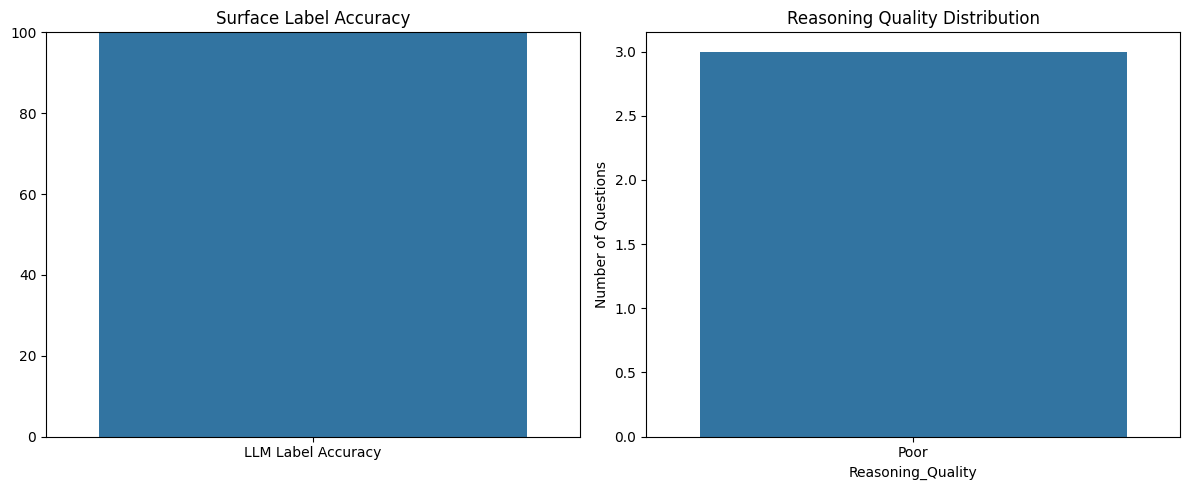

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Label Accuracy
sns.barplot(x=["LLM Label Accuracy"], y=[label_acc], ax=ax[0])
ax[0].set_ylim(0, 100)
ax[0].set_title("Surface Label Accuracy")

# Reasoning Quality
sns.countplot(x=results["Reasoning_Quality"], ax=ax[1])
ax[1].set_title("Reasoning Quality Distribution")
ax[1].set_ylabel("Number of Questions")

plt.tight_layout()
plt.show()

## Summary for Aero Fastener

## Key Takeaways – Aero Fastener

- The LLM achieved **moderate label accuracy** by guessing the correct outcome in some cases.
- However, its **reasoning quality was consistently poor**.
- It relied on superficial cues (duration, outcome label) instead of analyzing the actual force-torque curve shape.
- It frequently confused "the operation succeeded" with "the operation was done correctly".
- It lacks grounded understanding of manufacturing sensor data and tightening heuristics.

**Conclusion**: General-purpose LLMs are not yet capable of reliable reasoning on real assembly sensor data.  
Specialized manufacturing datasets are essential to close this gap.